## 1. Environment Setup
Run this cell to clone the repository, navigate into it, and install required dependencies.

In [2]:
# Clone the entire repo.
!git clone -l -s https://github.com/lelandweeks/CS615-FinalProject CS615-FinalProject
%cd CS615-FinalProject

# Install required packages
!pip install gdown

Cloning into 'CS615-FinalProject'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 166 (delta 107), reused 131 (delta 78), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 26.27 MiB | 43.04 MiB/s, done.
Resolving deltas: 100% (107/107), done.
/content/CS615-FinalProject


## 2. Dataset Preparation
Run this cell to download the 2.5GB dataset from Google Drive, extract it, and properly place the images into the `images/` directory so the model can find them.

In [3]:
import gdown
import os

# Download the dataset from Google Drive
file_id = '1GVWC33hxsbPuSwM7JmJWujDpTObEYc8w'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'dataset.tar'
gdown.download(url, output, quiet=True)

# Extract the tar file
print("Extracting dataset...")
!tar -xf dataset.tar

# Clean up any existing destination directory and recreate it
!rm -rf images
!mkdir -p images

# Move the extracted dataset contents into the project directory's images folder
!mv MiDaS-60_small/* images/

print("Dataset extracted and aligned to 'images/' successfully.")

Extracting dataset...
Dataset extracted and aligned to 'images/' successfully.


## 3. Training and Evaluation
Use this section to run the model training and evaluation commands. The first two commands are lightweight tests to verify the setup.

In [6]:
# Make sure you have the most recent changes to the code base
import os
if os.path.basename(os.getcwd()) != 'CS615-FinalProject':
    os.chdir('/content/CS615-FinalProject')

!git pull


remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 430 bytes | 430.00 KiB/s, done.
From https://github.com/lelandweeks/CS615-FinalProject
   65faac7..c5ae7a2  main       -> origin/main
Updating 65faac7..c5ae7a2
Fast-forward
 src/data.py | 7 ++++---
 1 file changed, 4 insertions(+), 3 deletions(-)


Testing the Training Pipeline...
Using device: cuda
Mode: train, Color: True, Kernels: 1, Kernel Size: 3, Layers: 1
Model Filename:  model_color_1k_3x3_1l.pt
Loss Plot Filename:  plot_color_1k_3x3_1l.png
Confusion Matrix Filename:  cm_color_1k_3x3_1l.png
Setting up the data loaders...
Number of training samples: 32400
Number of test samples: 3600
Training with pareamters: Epochs: 1, Learning Rate: 0.001
Epoch [1/1], Loss: 4.1634, Time: 30.30s

Testing the Evaluation Pipeline...
Using device: cuda
Mode: evaluate, Color: True, Kernels: 1, Kernel Size: 3, Layers: 1
Model Filename:  model_color_1k_3x3_1l.pt
Loss Plot Filename:  plot_color_1k_3x3_1l.png
Confusion Matrix Filename:  cm_color_1k_3x3_1l.png
Setting up the data loaders...
Number of training samples: 32400
Number of test samples: 3600
Final Test Accuracy: 1.67%

Displaying the generated plot:


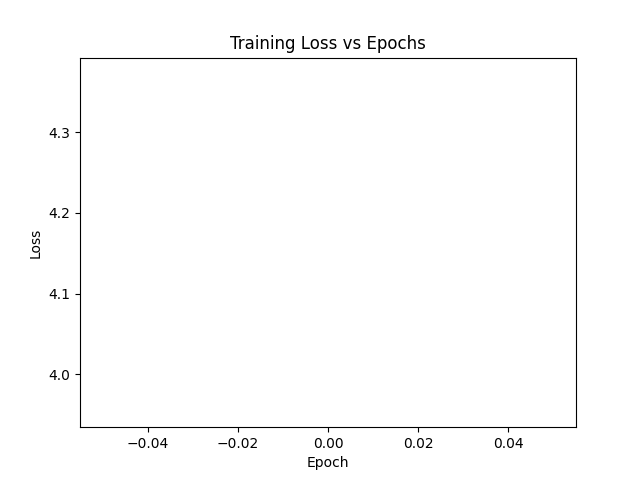


Displaying the generated confusion matrix:


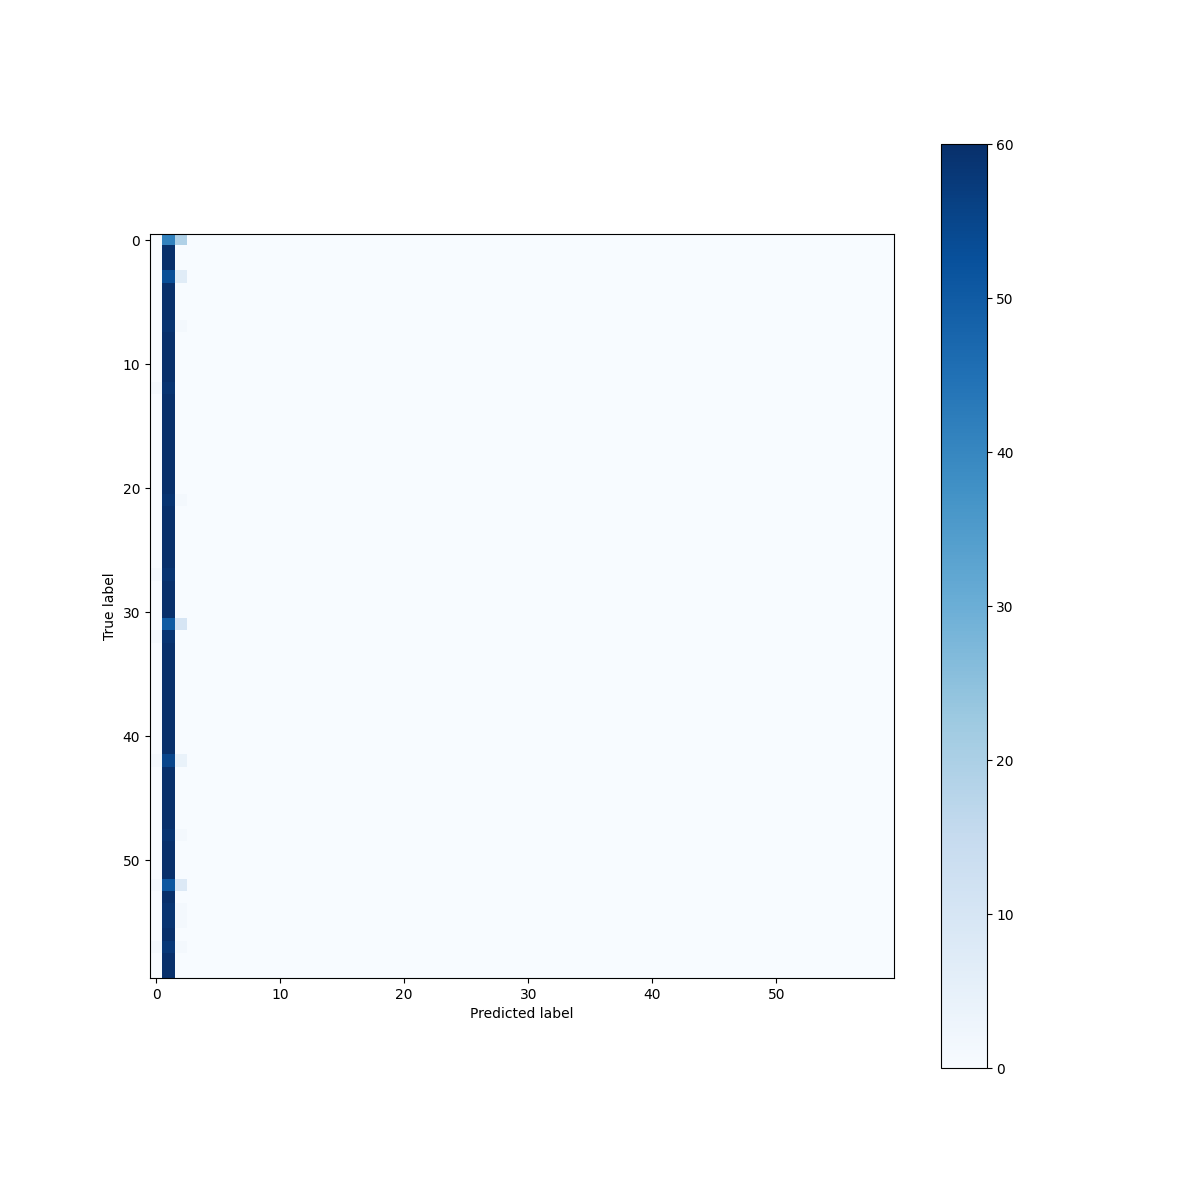

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import os
import time
from IPython.display import Image, display
from google.colab import files

if os.path.basename(os.getcwd()) != 'CS615-FinalProject':
    os.chdir('/CS615-FinalProject')

# --- Test Setup ---
print("Testing the Training Pipeline...")
!python src/main.py --mode train --kernels 1 --epochs 1

print("\nTesting the Evaluation Pipeline...")
!python src/main.py --mode evaluate --kernels 1 --epochs 1

# --- Display Plot ---
plot_path = 'plots/plot_color_1k_3x3_1l.png'
if os.path.exists(plot_path):
    print("\nDisplaying the generated plot:")
    display(Image(filename=plot_path))

cm_path = 'plots/cm_color_1k_3x3_1l.png'
if os.path.exists(cm_path):
    print("\nDisplaying the generated confusion matrix:")
    display(Image(filename=cm_path))

# --- Download Artifacts ---
model_path = 'models/model_color_1k_3x3_1l.pt'
print("\nDownloading artifacts...")

# Adding a short delay between downloads to prevent browser blocking
if os.path.exists(plot_path):
    print(f"Downloading {plot_path}...")
    files.download(plot_path)
    time.sleep(1)

if os.path.exists(cm_path):
    print(f"Downloading {cm_path}...")
    files.download(cm_path)
    time.sleep(1)

if os.path.exists(model_path):
    print(f"Downloading {model_path}...")
    files.download(model_path)